Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [3]:
df = pd.read_csv("European_Bank.csv")

Check dataset

In [4]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Check Missing Values

In [5]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Remove useless columns

In [6]:
df.drop(
columns=[
"CustomerId",
"Surname"
],
inplace=True)

Check the Year column

In [7]:
df["Year"].value_counts()

Year
2025    10000
Name: count, dtype: int64

In [8]:
df.drop(columns=["Year"], inplace=True)

Exploratory Data Analysis (EDA)

Churn Distribution

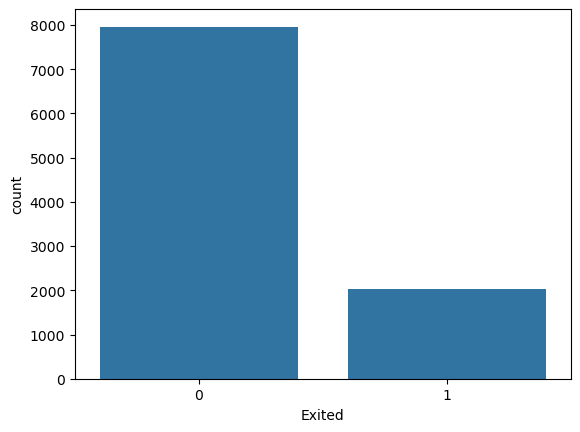

In [9]:
sns.countplot(x="Exited", data=df)
plt.show()

Churn by Geography

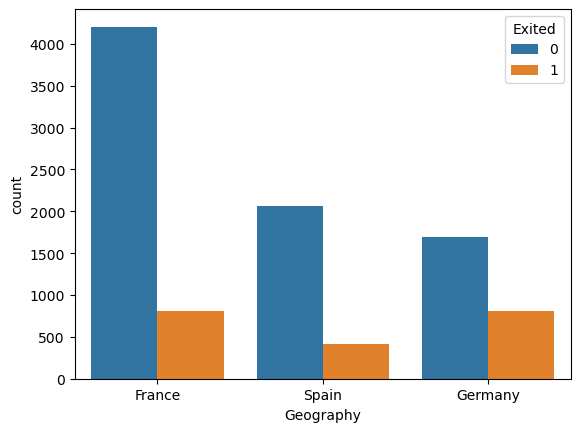

In [10]:
sns.countplot(x="Geography", hue="Exited", data=df)
plt.show()

Churn by Gender

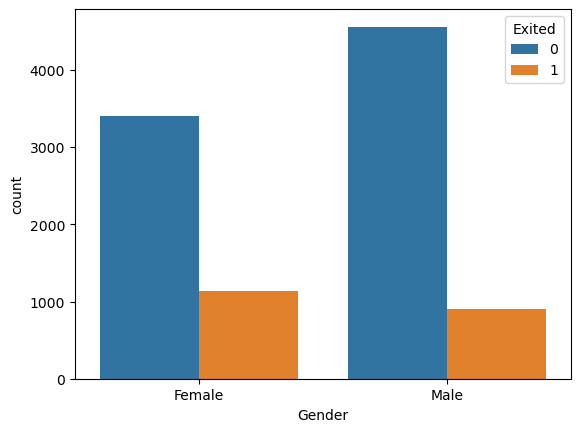

In [11]:
sns.countplot(x="Gender", hue="Exited", data=df)
plt.show()

Age Distribution

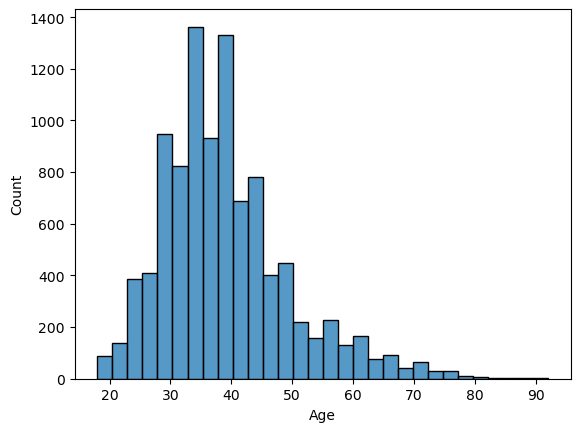

In [12]:
sns.histplot(df["Age"], bins=30)
plt.show()

Age vs Churn

<Axes: xlabel='Exited', ylabel='Age'>

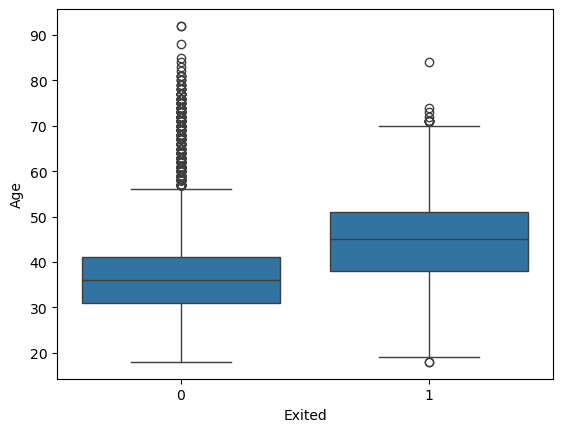

In [13]:
sns.boxplot(
x="Exited",
y="Age",
data=df
)

Correlation Heatmap

<Axes: >

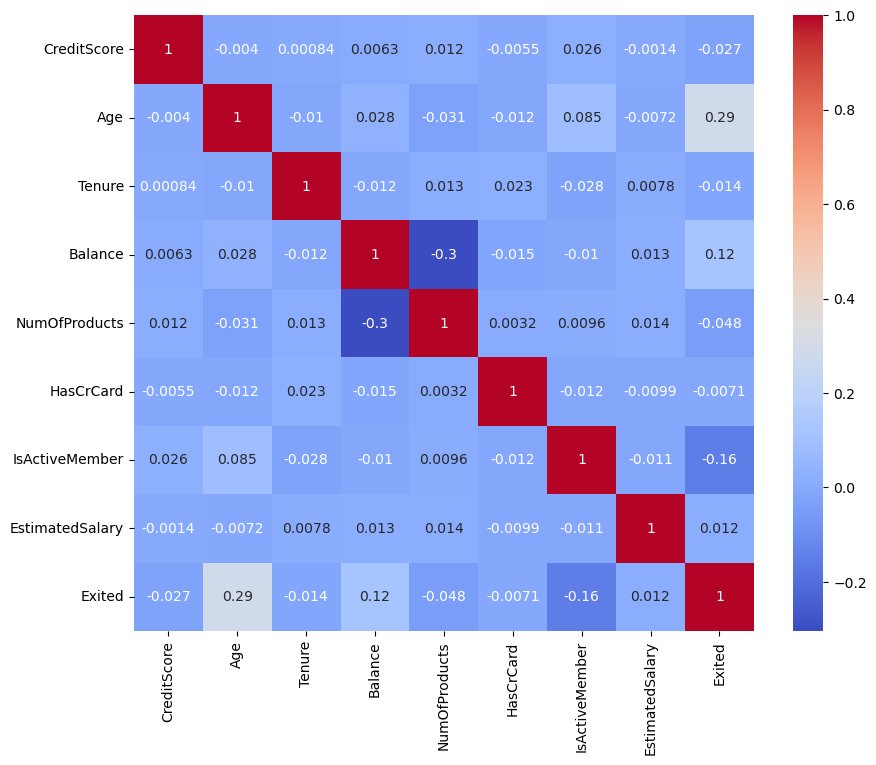

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(
df.corr(numeric_only=True),
annot=True,
cmap="coolwarm"
)

Feature Engineering

Balance to Salary Ratio

In [15]:
df["BalanceSalaryRatio"] = (
df["Balance"] /
(df["EstimatedSalary"] + 1)
)

Product Density

In [16]:
df["ProductDensity"] = (
df["NumOfProducts"] /
(df["Tenure"] + 1)
)

Engagement Score

In [17]:
df["Engagement"] = (
df["IsActiveMember"] *
df["NumOfProducts"]
)

Age × Tenure

In [18]:
df["AgeTenure"] = (
df["Age"] *
df["Tenure"]
)

Encode Categorical Variables

In [19]:
df = pd.get_dummies(
df,
columns=[
"Geography",
"Gender"
],
drop_first=True
)

Separate Features and Target

In [20]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

Scale Numerical Features

In [22]:
scaler = StandardScaler()

cols = [
"CreditScore",
"Age",
"Balance",
"EstimatedSalary",
"Tenure"
]

X_train[cols] = scaler.fit_transform(X_train[cols])

X_test[cols] = scaler.transform(X_test[cols])

Build Models

Logistic Regression

In [23]:
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Decision Tree

In [24]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

Random Forest

In [25]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

Gradient Boosting

In [26]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

Evaluate Models

In [27]:
def evaluate(y_true, pred):

    print("Accuracy :", accuracy_score(y_true,pred))
    print("Precision:", precision_score(y_true,pred))
    print("Recall   :", recall_score(y_true,pred))
    print("F1 Score :", f1_score(y_true,pred))

    print(classification_report(y_true,pred))

In [28]:
evaluate(y_test,pred_rf)

Accuracy : 0.8655
Precision: 0.7827868852459017
Recall   : 0.4692874692874693
F1 Score : 0.5867895545314901
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



Feature Importance

In [29]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance.sort_values(
"Importance",
ascending=False
).head(10)

,Feature,Importance
1,Age,0.192655
7,EstimatedSalary,0.103683
0,CreditScore,0.103366
3,Balance,0.098706
11,AgeTenure,0.093759
4,NumOfProducts,0.091080
8,BalanceSalaryRatio,0.082115
9,ProductDensity,0.052383
10,Engagement,0.045361
2,Tenure,0.039282


Model Comparison

In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_gb)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_gb)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, pred_lr),
        roc_auc_score(y_test, pred_dt),
        roc_auc_score(y_test, pred_rf),
        roc_auc_score(y_test, pred_gb)
    ]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.8685,0.785714,0.486486,0.600910,0.726294
2,Random Forest,0.8655,0.782787,0.469287,0.586790,0.718008
1,Decision Tree,0.7845,0.471292,0.484029,0.477576,0.672649
0,Logistic Regression,0.8065,0.573529,0.191646,0.287293,0.577618


Visualize Model Performance

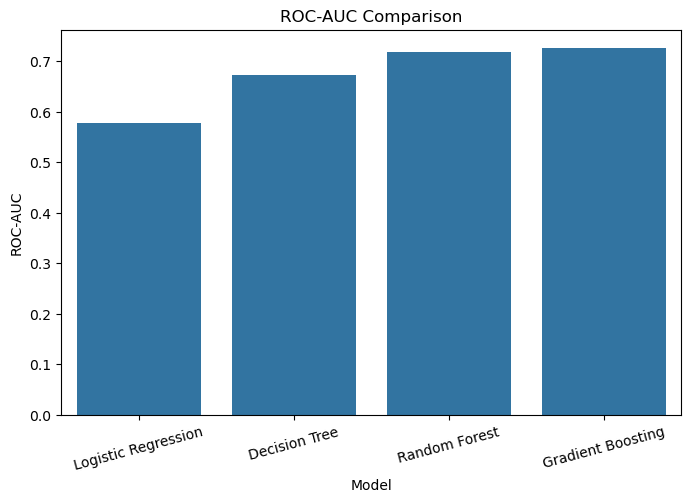

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison")
plt.xticks(rotation=15)

plt.show()

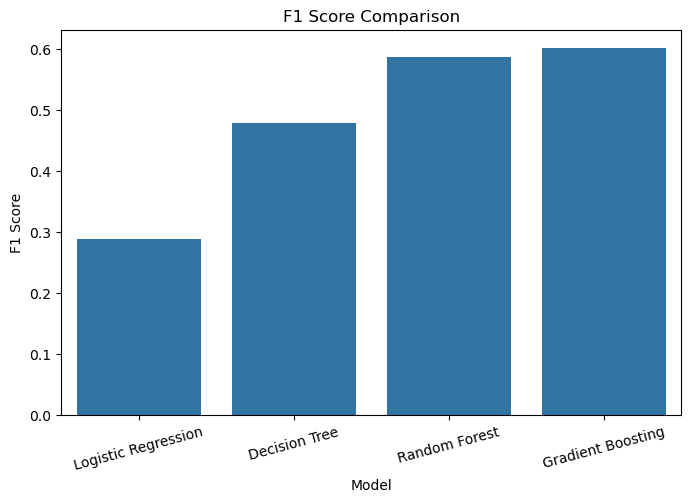

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison")
plt.xticks(rotation=15)

plt.show()

Customer Risk Scoring

In [33]:
probability = rf.predict_proba(X_test)

probability[:5]

array([[0.97, 0.03],
       [0.9 , 0.1 ],
       [0.98, 0.02],
       [0.98, 0.02],
       [0.93, 0.07]])

In [34]:
churn_probability = probability[:,1]

Create Risk Levels

In [36]:
risk = []

for p in churn_probability:

    if p < 0.30:
        risk.append("Low")

    elif p < 0.70:
        risk.append("Medium")

    else:
        risk.append("High")

Create final output:

In [37]:
prediction_df = X_test.copy()

prediction_df["Actual"] = y_test.values

prediction_df["Prediction"] = pred_rf

prediction_df["Probability"] = churn_probability

prediction_df["Risk"] = risk

prediction_df.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,Engagement,AgeTenure,Geography_Germany,Geography_Spain,Gender_Male,Actual,Prediction,Probability,Risk
5702,-0.680735,-0.279932,0.684723,-1.226059,2,1,0,-0.095021,0.000000,0.250000,0,252,False,False,True,0,0,0.03,Low
3667,-1.301915,-0.564935,-0.350971,0.877113,2,0,0,-0.778941,2.379052,0.400000,0,132,True,False,True,0,0,0.10,Low
1617,-0.970619,0.100072,-0.350971,-1.226059,2,0,1,0.099469,0.000000,0.400000,2,160,False,True,False,0,0,0.02,Low
5673,-0.121674,-0.469934,-0.005739,1.011458,2,0,0,-1.147374,4.105707,0.333333,0,170,False,True,True,0,0,0.02,Low
4272,-0.111321,-0.469934,-0.696202,0.023204,1,1,1,1.200283,0.461754,0.250000,1,102,False,True,False,0,0,0.07,Low
8270,-0.949913,-0.469934,-1.731895,-1.226059,1,1,0,1.452222,0.000000,1.000000,0,0,False,True,True,0,0,0.24,Low
7079,-0.577205,-0.849937,1.375185,0.871629,2,1,1,-0.730278,2.258440,0.200000,2,270,True,False,True,0,0,0.03,Low
5295,0.571977,-0.944938,0.339492,1.752269,1,1,0,1.243763,1.084810,0.142857,0,174,True,False,False,0,0,0.16,Low
845,-1.508975,0.955079,0.684723,0.058108,1,0,0,0.618321,0.591808,0.125000,0,343,False,False,True,0,1,0.51,Medium
5311,0.654801,0.100072,-1.731895,-1.226059,2,1,0,-0.644823,0.000000,2.000000,0,0,False,False,False,0,0,0.04,Low


Business Insights

-Older customers show a higher likelihood of churn.
-Inactive members are more likely to leave the bank.
-Customers with fewer banking products exhibit higher churn rates.
-Geography influences customer churn behaviour.
-Customers identified as High Risk should be prioritized for retention campaigns.

Conclusion

In this project, multiple machine learning algorithms were developed and compared to predict customer churn. Random Forest achieved the best overall performance and was selected as the final model. The model generates customer churn probabilities and assigns risk levels that can support proactive customer retention strategies. Feature importance analysis identified the key factors influencing churn, enabling more informed business decisions.

Save the Best Model

In [38]:
import joblib

joblib.dump(rf, "churn_model.pkl")

['churn_model.pkl']

In [39]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']